In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
df=pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [97]:
print("Dataset shape :",df.shape)

Dataset shape : (545, 13)


In [98]:
print("Number of rows :",df.shape[0])
print("Number of columns :",df.shape[1])

Number of rows : 545
Number of columns : 13


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [100]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [101]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [102]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [103]:
target="price"
print("Target column :",target)
features=[col for col in df.columns if col!=target]
print("Features :")
for feature in features:
  print(feature)

Target column : price
Features :
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus


The Housing dataset contains 545 records and 13 columns.

The target variable is price.
There are 12 feature variables describing house characteristics.

The dataset contains both numerical and categorical features.

No missing values were found in the dataset.

Further preprocessing is required to convert categorical variables into numerical format before model training.

In [104]:
duplicates=df.duplicated().sum()
print("Duplicated rows ",duplicates)

Duplicated rows  0


In [105]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates :", df.shape)

Dataset shape after removing duplicates : (545, 13)


In [106]:
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_1382/3601443743.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [107]:
categorical_cols=df.select_dtypes(include='object').columns
print("Categorical columns :")
print(categorical_cols)

Categorical columns :
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [108]:
for col in categorical_cols:
  print(col)
  print(df[col].unique())
  print()

mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']



In [109]:
df_encoded=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [110]:
print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [111]:
print(df_encoded.shape)

(545, 14)


In [112]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [113]:
bool_cols=df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols]=df_encoded[bool_cols].astype(int)

In [114]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [115]:
x=df_encoded.drop(target,axis=1)
y=df_encoded[target]

In [116]:
print("Features of X :",x.shape)
print("Features of Y :",y.shape)

Features of X : (545, 13)
Features of Y : (545,)


In [117]:
print(x.columns.tolist())

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [118]:
print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

In [120]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    )
print("Shape of x_train :",x_train.shape)
print("Shape of x_test :",x_test.shape)
print("Shape of y_train :",y_train.shape)
print("Shape of y_test :",y_test.shape)

Shape of x_train : (436, 13)
Shape of x_test : (109, 13)
Shape of y_train : (436,)
Shape of y_test : (109,)


In [122]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

In [123]:
y_pred_lr=lr_model.predict(x_test)

In [126]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse_lr=mean_squared_error(y_test,y_pred_lr)
rmse_lr=mse_lr**0.5
mae_lr=mean_absolute_error(y_test,y_pred_lr)
r2_score_lr=r2_score(y_test,y_pred_lr)
print("Linear Regression model :")
print("Mean Squared Error :",mse_lr)
print("Root mean squared error :",rmse_lr)
print("Mean Absolute Error :",mae_lr)
print("R2 Score :",r2_score_lr)

Linear Regression model :
Mean Squared Error : 1754318687330.6638
Root mean squared error : 1324506.9600914386
Mean Absolute Error : 970043.4039201636
R2 Score : 0.6529242642153184


In [135]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [136]:
y_pred_rf=rf_model.predict(x_test)

In [137]:
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=mse_rf**0.5
mae_rf=mean_absolute_error(y_test,y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print("Random Forest model :")
print("Mean Squared Error :",mse_rf)
print("Root mean squared error :",rmse_rf)
print("Mean Absolute Error :",mae_rf)
print("R2 Score :",r2_rf)

Random Forest model :
Mean Squared Error : 1961585044320.3433
Root mean squared error : 1400565.9728553821
Mean Absolute Error : 1021546.0353211008
R2 Score : 0.611918531405699


In [138]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_score_lr,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


Since Linear Regression produced lower error values and a higher R² Score, it was selected as the better-performing model for this dataset.

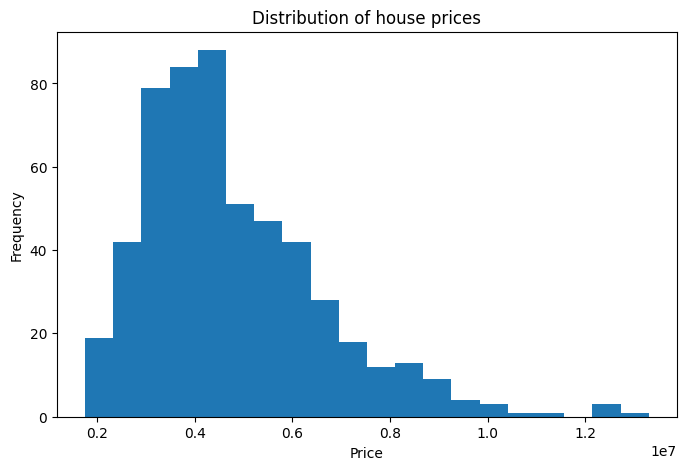

In [149]:
plt.figure(figsize=(8,5))
plt.hist(df['price'],bins=20)

plt.title("Distribution of house prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig('house_price_distribution.png',bbox_inches='tight')
plt.show()

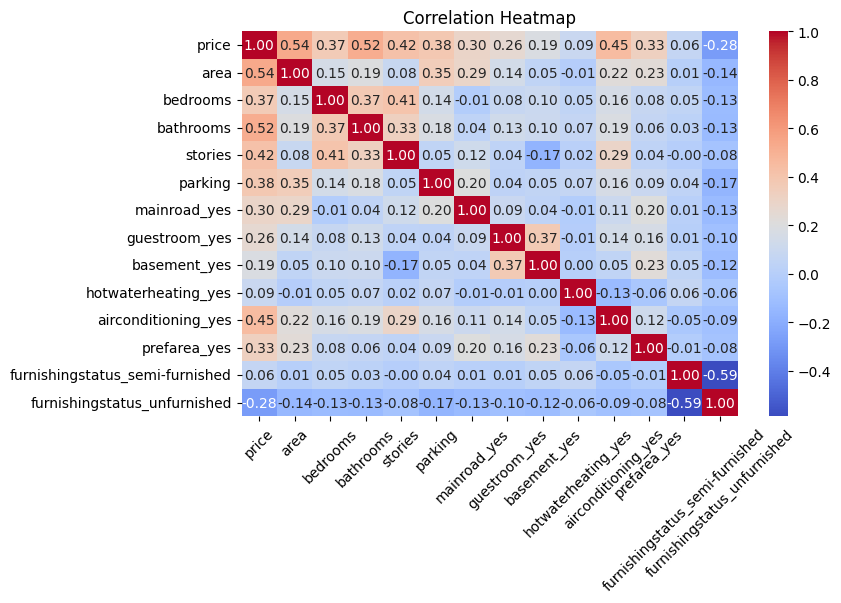

In [150]:
plt.figure(figsize=(8,5))
sns.heatmap(df_encoded.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.xticks(rotation=45,)
plt.yticks(rotation=0,ha='right')
plt.savefig('correlation_heatmap.png',bbox_inches='tight')
plt.show()

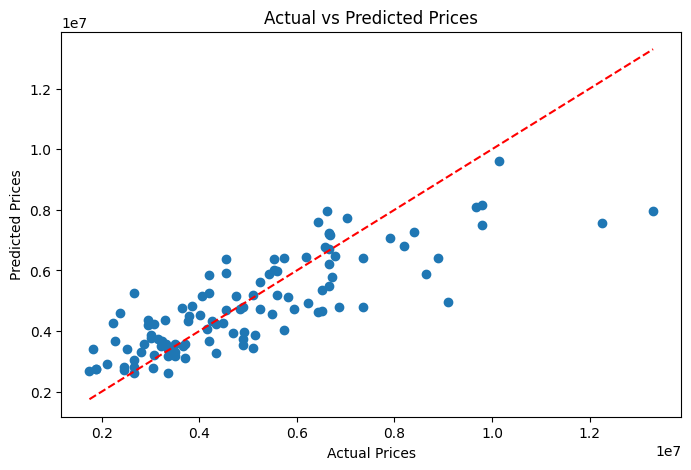

In [151]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_lr)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.savefig('actual_predicted_prices.png',bbox_inches='tight')
plt.show()

Points closer to the diagonal line indicate more accurate predictions. Most predictions follow the trend of actual prices, showing reasonable model performance.

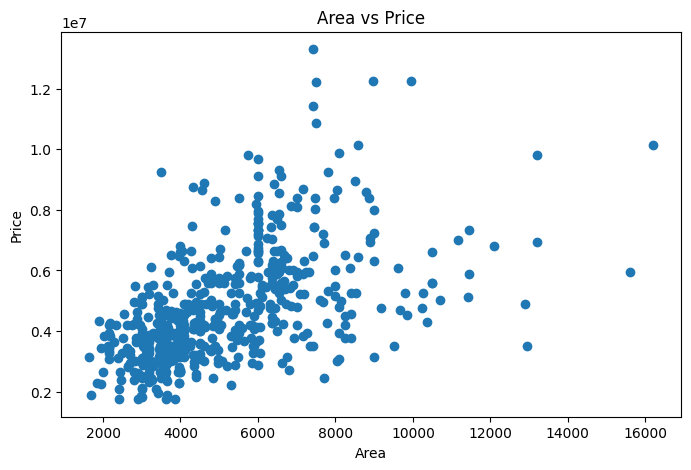

In [152]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'],df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.savefig('area_vs_price_plot.png',bbox_inches='tight')
plt.show()

Larger houses generally tend to have higher prices, indicating a positive relationship between area and house value.

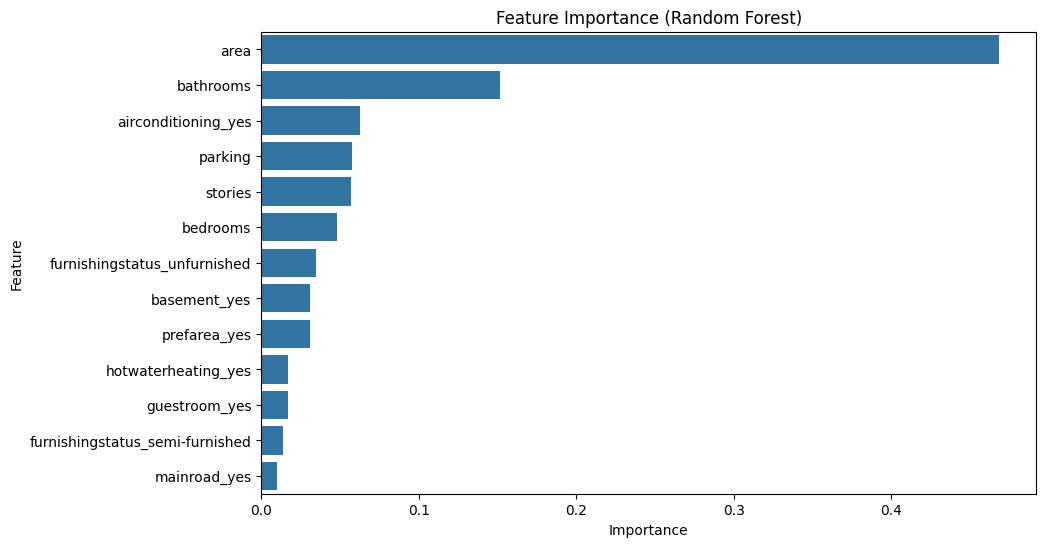

In [153]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance (Random Forest)')
plt.savefig("feature_importance_rf.png",bbox_inches='tight')

plt.show()

### Insights & Summary

Based on the correlation analysis, the most influential features affecting house prices were area, number of bathrooms, air conditioning, stories, and parking availability. Among these, area and bathrooms showed the strongest positive correlation with price.

The Linear Regression model achieved an R² score of approximately 0.65, which means it was able to explain about 65% of the variation in house prices and provided reasonably accurate predictions.

 One interesting observation was that the presence of air conditioning had a stronger impact on price than some structural features such as guest rooms and basements.Additionally, unfurnished houses showed a negative correlation with price, indicating that furnishing status affects property value.

  Based on these findings, real estate businesses should highlight larger house areas, modern amenities, sufficient parking, and air conditioning features when marketing properties, as these factors are strongly associated with higher selling prices.
